# XAI Methods for Medical Imaging — Demo Notebook

## Overview
This notebook demonstrates **Explainable AI (XAI) methods** applied to dermatology image classification on the **ISIC 2019** dataset.

**Contents:**
1. Installation & Configuration
2. Configuration & Constants
3. Dataset Verification
4. Model Loading (pretrained weights)
5. XAI Methods (Grad-CAM, Attention Rollout, Generic Attention, Integrated Gradients, LIME)
6. Demonstration & Visualization
7. Quantitative Evaluation (Insertion/Deletion AUC)
8. Sanity Checks
9. Summary

> **Note:** Model training is handled in separate notebooks:
> - `train_cnn.ipynb` — ResNet-50, EfficientNet-B4
> - `train_hybrid.ipynb` — ConvNeXt-Base, Swin-Base
> - `train_vit.ipynb` — ViT-Base, DeiT-Base

## 1. Installation et Configuration

In [ ]:
import os
import requests
import zipfile

# ---------------------------------------
# Base directory
# ---------------------------------------
base_dir = "/kaggle/working/xai_medical_imaging/data/ISIC2019"
os.makedirs(base_dir, exist_ok=True)

# ---------------------------------------
# URLs
# ---------------------------------------
urls = {
    "train_zip": "https://isic-archive.s3.amazonaws.com/challenges/2019/ISIC_2019_Training_Input.zip",
    "train_csv": "https://isic-archive.s3.amazonaws.com/challenges/2019/ISIC_2019_Training_GroundTruth.csv",

    "test_zip": "https://isic-archive.s3.amazonaws.com/challenges/2019/ISIC_2019_Test_Input.zip",
    "test_csv": "https://isic-archive.s3.amazonaws.com/challenges/2019/ISIC_2019_Test_GroundTruth.csv",
}

# ---------------------------------------
# Download file
# ---------------------------------------
def download(url, dest):
    print(f"Downloading {dest} ...")
    r = requests.get(url)
    with open(dest, "wb") as f:
        f.write(r.content)
    print(f"✔ Done.")

# ---------------------------------------
# Extract ZIP then remove it
# ---------------------------------------
def extract_and_remove(zip_path, extract_to):
    print(f"Extracting {zip_path} ...")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_to)
    print("✔ Extracted.")

    print(f"Removing {zip_path} ...")
    os.remove(zip_path)
    print("✔ Removed.")

# ---------------------------------------
# STEP 1 — Training dataset
# ---------------------------------------

# Download train ZIP
train_zip_path = f"{base_dir}/ISIC_2019_Training_Input.zip"
download(urls["train_zip"], train_zip_path)

# Extract and delete train ZIP
extract_and_remove(train_zip_path, base_dir)

# Download train CSV
download(urls["train_csv"], f"{base_dir}/ISIC_2019_Training_GroundTruth.csv")

# ---------------------------------------
# STEP 2 — Test dataset
# ---------------------------------------

# Download test ZIP
test_zip_path = f"{base_dir}/ISIC_2019_Test_Input.zip"
download(urls["test_zip"], test_zip_path)

# Extract and delete test ZIP
extract_and_remove(test_zip_path, base_dir)

# Download test CSV
download(urls["test_csv"], f"{base_dir}/ISIC_2019_Test_GroundTruth.csv")

print("\n✔ Dataset fully downloaded, extracted, and cleaned.")


In [ ]:
# ============================================
# INSTALLATION DES DÉPENDANCES
# ============================================
# Décommenter et exécuter si nécessaire

!pip install --upgrade pip
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118
!pip install timm==0.9.12
!pip install grad-cam # Removed version constraint
!pip install captum==0.7.0
!pip install lime==0.2.0.1
!pip install albumentations==1.3.1
!pip install scikit-learn pandas matplotlib seaborn tqdm

In [1]:
# ============================================
# IMPORTS
# ============================================
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import timm

# XAI Libraries
from captum.attr import IntegratedGradients, Saliency

# Configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Ajouter le path du projet
sys.path.insert(0, '..')

# Seed pour reproductibilité
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Device: cpu


## 2. Configuration et Constantes

In [2]:
# ============================================
# CONFIGURATION
# ============================================

# Dataset - AJUSTER SELON VOTRE CONFIGURATION
DATA_DIR = '../data/ISIC2019'
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 4

# Classes ISIC 2019 (8 classes)
CLASS_NAMES = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC']

CLASS_NAMES_FULL = {
    'MEL': 'Melanome',
    'NV': 'Naevus melanocytaire',
    'BCC': 'Carcinome basocellulaire',
    'AK': 'Keratose actinique',
    'BKL': 'Keratose benigne',
    'DF': 'Dermatofibrome',
    'VASC': 'Lesion vasculaire',
    'SCC': 'Carcinome epidermoide'
}

NUM_CLASSES = len(CLASS_NAMES)

# Normalisation ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

print(f"Configuration:")
print(f"   - Image size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"   - Batch size: {BATCH_SIZE}")
print(f"   - Nombre de classes: {NUM_CLASSES}")
print(f"\nClasses ISIC 2019:")
for i, (abbr, full) in enumerate(CLASS_NAMES_FULL.items()):
    print(f"   {i}. {abbr}: {full}")

Configuration:
   - Image size: 224x224
   - Batch size: 32
   - Nombre de classes: 8

Classes ISIC 2019:
   0. MEL: Melanome
   1. NV: Naevus melanocytaire
   2. BCC: Carcinome basocellulaire
   3. AK: Keratose actinique
   4. BKL: Keratose benigne
   5. DF: Dermatofibrome
   6. VASC: Lesion vasculaire
   7. SCC: Carcinome epidermoide


## 3. Vérification du Dataset

In [3]:
# ============================================
# VÉRIFIER LE DATASET
# ============================================

dataset_available = os.path.exists(DATA_DIR)

if dataset_available:
    csv_path = os.path.join(DATA_DIR, 'ISIC_2019_Training_GroundTruth.csv')
    img_dir = os.path.join(DATA_DIR, 'ISIC_2019_Training_Input')

    if os.path.exists(csv_path) and os.path.exists(img_dir):
        df = pd.read_csv(csv_path)
        print(f"Dataset ISIC trouve!")
        print(f"\nStatistiques:")
        print(f"   - Total images: {len(df)}")
        print(f"\nDistribution des classes:")
        for cls in CLASS_NAMES:
            if cls in df.columns:
                count = df[cls].sum()
                pct = count / len(df) * 100
                print(f"   - {cls}: {count:,} ({pct:.1f}%)")
    else:
        dataset_available = False

if not dataset_available:
    print("Dataset ISIC non trouve!")
    print("\nInstructions de telechargement:")
    print("   1. Aller sur: https://challenge.isic-archive.com/data/#2019")
    print("   2. Telecharger 'ISIC_2019_Training_Input.zip' (~9GB)")
    print("   3. Telecharger 'ISIC_2019_Training_GroundTruth.csv'")
    print(f"   4. Extraire dans: {DATA_DIR}")
    print("\n   Structure attendue:")
    print("   data/ISIC2019/")
    print("   ├── ISIC_2019_Training_Input/")
    print("   │   ├── ISIC_0000000.jpg")
    print("   │   └── ...")
    print("   └── ISIC_2019_Training_GroundTruth.csv")

Dataset ISIC trouve!

Statistiques:
   - Total images: 25331

Distribution des classes:
   - MEL: 4,522.0 (17.9%)
   - NV: 12,875.0 (50.8%)
   - BCC: 3,323.0 (13.1%)
   - AK: 867.0 (3.4%)
   - BKL: 2,624.0 (10.4%)
   - DF: 239.0 (0.9%)
   - VASC: 253.0 (1.0%)
   - SCC: 628.0 (2.5%)


## 4. Création des Modèles

In [4]:
# ============================================
# WRAPPER DE MODÈLES
# ============================================

class ModelWrapper(nn.Module):
    """Wrapper unifie pour CNN et ViT."""

    def __init__(self, model_name, num_classes, pretrained=True):
        super().__init__()
        self.model_name = model_name
        self.num_classes = num_classes
        self.model = timm.create_model(model_name, pretrained=pretrained, num_classes=num_classes)
        self.model_type = self._get_model_type()

    def _get_model_type(self):
        vit_keywords = ["vit", "deit", "swin", "beit"]
        if any(kw in self.model_name.lower() for kw in vit_keywords):
            return "transformer"
        return "cnn"

    def forward(self, x):
        return self.model(x)

    def get_target_layer(self):
        if "resnet" in self.model_name:
            return self.model.layer4[-1]
        elif "efficientnet" in self.model_name:
            return self.model.conv_head
        elif "vit" in self.model_name or "deit" in self.model_name:
            return self.model.blocks[-1].norm1
        elif "convnext" in self.model_name:
            return self.model.stages[-1].blocks[-1]
        else:
            return list(self.model.children())[-2]


# ============================================
# SWIN-BASE + BATCHFORMER
# Architecture identique à celle utilisée lors de l'entraînement
# ============================================

class BatchFormerBlock(nn.Module):
    """Cross-sample self-attention sur la dimension batch (Anaissi et al. 2026)."""
    def __init__(self, d_model, nhead=8, dropout=0.1):
        super().__init__()
        while nhead > 1 and d_model % nhead != 0:
            nhead -= 1
        self.attn  = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff    = nn.Sequential(
            nn.Linear(d_model, d_model * 4), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model), nn.Dropout(dropout),
        )

    def forward(self, x):
        x_seq = x.unsqueeze(0)
        attn_out, _ = self.attn(x_seq, x_seq, x_seq)
        x_out = self.norm1(x + attn_out.squeeze(0))
        return self.norm2(x_out + self.ff(x_out))


class SwinWithBatchFormerWrapper(nn.Module):
    """Swin-Base + BatchFormer — interface compatible avec le reste du demo."""

    def __init__(self, num_classes=8, pretrained=False, drop_path_rate=0.1):
        super().__init__()
        self.model_name = "swin_base_patch4_window7_224"
        self.model_type = "transformer"
        self.backbone = timm.create_model(
            "swin_base_patch4_window7_224",
            pretrained=pretrained,
            num_classes=0,
            drop_path_rate=drop_path_rate,
        )
        in_features = self.backbone.num_features  # 1024
        self.batch_former = BatchFormerBlock(d_model=in_features)
        self.head = nn.Linear(in_features, num_classes)

    def forward(self, x):
        features = self.backbone(x)
        features = self.batch_former(features)
        return self.head(features)

    def get_target_layer(self):
        return self.backbone.layers[-1].blocks[-1].norm1


print("ModelWrapper defini")
print("SwinWithBatchFormerWrapper defini")


ModelWrapper defini
SwinWithBatchFormerWrapper defini


In [5]:
# ============================================
# CRÉER LES 6 MODÈLES ET CHARGER LES POIDS ENTRAÎNÉS
# ============================================

print("Chargement des 6 modèles avec poids entraînés...\n")

MODELS_CONFIG = {
    'resnet50':        {'timm_name': 'resnet50',                     'type': 'CNN',         'batch_size': 32,  'lr': 1e-4,  'weights': '../results/resnet50_best.pth'},
    'efficientnet_b4': {'timm_name': 'efficientnet_b4',              'type': 'CNN',         'batch_size': 24,  'lr': 1e-4,  'weights': '../results/efficientnet_b4_best.pth'},
    'convnext_base':   {'timm_name': 'convnext_base',                'type': 'CNN-Modern',  'batch_size': 16,  'lr': 5e-5,  'weights': '../results/convnext_base_best.pth'},
    'vit_base':        {'timm_name': 'vit_base_patch16_224',         'type': 'Transformer', 'batch_size': 16,  'lr': 1e-5,  'weights': '../results/vit_base_patch16_best.pth'},
    'deit_base':       {'timm_name': 'deit_base_patch16_224',        'type': 'Transformer', 'batch_size': 16,  'lr': 1e-5,  'weights': '../results/deit_base_patch16_best.pth'},
    'swin_base':       {'timm_name': 'swin_base_patch4_window7_224', 'type': 'Transformer', 'batch_size': 16,  'lr': 1e-5,  'weights': '../results/swin_base_batchformer_best.pth'},
}

models = {}

for name, cfg in MODELS_CONFIG.items():
    model_type = cfg['type']
    weights_path = cfg['weights']
    print(f"{name} ({model_type})...")

    try:
        # Créer l'architecture (sans poids pretrained — on charge nos propres poids)
        if name == 'swin_base':
            model = SwinWithBatchFormerWrapper(NUM_CLASSES, pretrained=False).to(device)
        else:
            model = ModelWrapper(cfg['timm_name'], NUM_CLASSES, pretrained=False).to(device)

        # Charger les poids entraînés
        if os.path.exists(weights_path):
            ckpt = torch.load(weights_path, map_location=device, weights_only=False)
            state_dict = ckpt.get('model_state_dict', ckpt)

            if name == 'swin_base':
                model.load_state_dict(state_dict)
            else:
                model.model.load_state_dict(state_dict)

            val_acc  = ckpt.get('val_acc', '?')
            val_loss = ckpt.get('val_loss', '?')
            epoch    = ckpt.get('epoch', '?')
            val_acc_str = f"{val_acc:.4f}" if isinstance(val_acc, float) else str(val_acc)
            print(f"   ✓ Poids chargés — epoch={epoch}, val_acc={val_acc_str}")
        else:
            print(f"   ⚠ Poids non trouvés: {weights_path}")
            print(f"     → Fallback sur poids ImageNet (pretrained=True)")
            if name == 'swin_base':
                model = SwinWithBatchFormerWrapper(NUM_CLASSES, pretrained=True).to(device)
            else:
                model = ModelWrapper(cfg['timm_name'], NUM_CLASSES, pretrained=True).to(device)

        model.eval()
        params = sum(p.numel() for p in model.parameters())
        print(f"   {params/1e6:.1f}M paramètres")
        models[name] = model

    except Exception as e:
        print(f"   ✗ Erreur: {e}")

print(f"\n{'='*50}")
print(f"✓ {len(models)}/6 modèles chargés avec poids entraînés!")
print(f"{'='*50}")

Chargement des 6 modèles avec poids entraînés...

resnet50 (CNN)...


   ✓ Poids chargés — epoch=19, val_acc=0.8282
   23.5M paramètres
efficientnet_b4 (CNN)...
   ✓ Poids chargés — epoch=7, val_acc=0.7873
   17.6M paramètres
convnext_base (CNN-Modern)...
   ✓ Poids chargés — epoch=21, val_acc=0.8582
   87.6M paramètres
vit_base (Transformer)...
   ✓ Poids chargés — epoch=28, val_acc=0.7890
   85.8M paramètres
deit_base (Transformer)...
   ✓ Poids chargés — epoch=27, val_acc=0.8323
   85.8M paramètres
swin_base (Transformer)...
   ✓ Poids chargés — epoch=1, val_acc=0.8471
   99.3M paramètres

✓ 6/6 modèles chargés avec poids entraînés!


## 5. Méthodes XAI

In [6]:
# ============================================
# 5.1 GRAD-CAM
# ============================================

class GradCAMExplainer:
    """Grad-CAM pour CNN et ViT."""

    def __init__(self, model, device='cuda'):
        self.model = model
        self.device = device
        self.target_layer = model.get_target_layer()
        self.gradients = None
        self.activations = None

        self.target_layer.register_forward_hook(self._save_activation)
        self.target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def explain(self, input_tensor, target_class=None):
        self.model.eval()
        input_tensor = input_tensor.to(self.device)
        input_tensor.requires_grad = True

        output = self.model(input_tensor)

        if target_class is None:
            target_class = output.argmax(dim=1).item()

        self.model.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot[0, target_class] = 1
        output.backward(gradient=one_hot, retain_graph=True)

        gradients = self.gradients
        activations = self.activations

        # Pour ViT: reshape si necessaire
        if self.model.model_type == 'transformer':
            if len(activations.shape) == 3:
                num_patches = activations.shape[1]
                if num_patches == 197:
                    activations = activations[:, 1:, :]
                    gradients = gradients[:, 1:, :]
                    num_patches = 196

                h = w = int(np.sqrt(num_patches))
                activations = activations.reshape(1, h, w, -1).permute(0, 3, 1, 2)
                gradients = gradients.reshape(1, h, w, -1).permute(0, 3, 1, 2)

        weights = gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=(224, 224), mode='bilinear', align_corners=False)

        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        return cam

print("GradCAMExplainer defini")

GradCAMExplainer defini


In [7]:
# ============================================
# 5.2 ATTENTION ROLLOUT
# ============================================

class AttentionRolloutExplainer:
    """Attention Rollout pour Vision Transformers."""

    def __init__(self, model, device='cuda'):
        if model.model_type != 'transformer':
            raise ValueError("Attention Rollout uniquement pour les Transformers")
        self.model = model
        self.device = device

    def explain(self, input_tensor, target_class=None, head_fusion='mean'):
        self.model.eval()
        input_tensor = input_tensor.to(self.device)

        attentions = []

        def hook_fn(module, input, output):
            B, N, C = input[0].shape
            qkv = module.qkv(input[0]).reshape(B, N, 3, module.num_heads, C // module.num_heads)
            qkv = qkv.permute(2, 0, 3, 1, 4)
            q, k, v = qkv[0], qkv[1], qkv[2]
            attn = (q @ k.transpose(-2, -1)) * (C // module.num_heads) ** -0.5
            attn = attn.softmax(dim=-1)
            attentions.append(attn.detach().cpu())

        hooks = []
        for block in self.model.model.blocks:
            hooks.append(block.attn.register_forward_hook(hook_fn))

        with torch.no_grad():
            _ = self.model(input_tensor)

        for hook in hooks:
            hook.remove()

        result = torch.eye(attentions[0].shape[-1])

        for attention in attentions:
            if head_fusion == 'mean':
                attention_heads_fused = attention.mean(dim=1)
            elif head_fusion == 'max':
                attention_heads_fused = attention.max(dim=1)[0]
            else:
                attention_heads_fused = attention.min(dim=1)[0]

            I = torch.eye(attention_heads_fused.shape[-1])
            a = (attention_heads_fused + I) / 2
            a = a / a.sum(dim=-1, keepdim=True)
            result = torch.matmul(a.squeeze(0), result)

        mask = result[0, 1:]
        num_patches = mask.shape[0]
        h = w = int(np.sqrt(num_patches))
        mask = mask.reshape(h, w).numpy()
        mask = cv2.resize(mask, (224, 224))
        mask = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)

        return mask

print("AttentionRolloutExplainer defini")

AttentionRolloutExplainer defini


In [8]:
# ============================================
# 5.3 GENERIC ATTENTION (CHEFER ET AL.)
# ============================================

class GenericAttentionExplainer:
    """
    Generic Attention pour ViT (Chefer et al., CVPR 2021).
    Reference: "Transformer Interpretability Beyond Attention Visualization"
    """

    def __init__(self, model, device='cuda'):
        if model.model_type != 'transformer':
            raise ValueError("Generic Attention uniquement pour les Transformers")
        self.model = model
        self.device = device

    def explain(self, input_tensor, target_class=None):
        self.model.eval()
        input_tensor = input_tensor.to(self.device)
        input_tensor.requires_grad = True

        attentions = []

        def forward_hook(module, input, output):
            B, N, C = input[0].shape
            qkv = module.qkv(input[0]).reshape(B, N, 3, module.num_heads, C // module.num_heads)
            qkv = qkv.permute(2, 0, 3, 1, 4)
            q, k, v = qkv[0], qkv[1], qkv[2]
            attn = (q @ k.transpose(-2, -1)) * (C // module.num_heads) ** -0.5
            attn = attn.softmax(dim=-1)
            attentions.append(attn)

        hooks = []
        for block in self.model.model.blocks:
            hooks.append(block.attn.register_forward_hook(forward_hook))

        output = self.model(input_tensor)

        if target_class is None:
            target_class = output.argmax(dim=1).item()

        self.model.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot[0, target_class] = 1
        output.backward(gradient=one_hot, retain_graph=True)

        for hook in hooks:
            hook.remove()

        num_tokens = attentions[0].shape[-1]
        R = torch.eye(num_tokens, device=self.device)

        for attn in attentions:
            attn = attn.squeeze(0)
            attn = attn.mean(dim=0)
            I = torch.eye(num_tokens, device=self.device)
            attn = (attn + I) / 2
            attn = attn / attn.sum(dim=-1, keepdim=True)
            R = torch.matmul(attn, R)

        mask = R[0, 1:].cpu().detach().numpy()
        num_patches = mask.shape[0]
        h = w = int(np.sqrt(num_patches))
        mask = mask.reshape(h, w)
        mask = cv2.resize(mask, (224, 224))
        mask = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)

        return mask

print("GenericAttentionExplainer defini (Chefer et al.)")

GenericAttentionExplainer defini (Chefer et al.)


In [9]:
# ============================================
# 5.4 INTEGRATED GRADIENTS
# ============================================

class IntegratedGradientsExplainer:
    """Integrated Gradients (Sundararajan et al., ICML 2017)."""

    def __init__(self, model, device='cuda', n_steps=50):
        self.model = model
        self.device = device
        self.n_steps = n_steps
        self.ig = IntegratedGradients(model)

    def explain(self, input_tensor, target_class=None, baseline=None):
        self.model.eval()
        input_tensor = input_tensor.to(self.device)

        if target_class is None:
            with torch.no_grad():
                output = self.model(input_tensor)
                target_class = output.argmax(dim=1).item()

        if baseline is None:
            baseline = torch.zeros_like(input_tensor).to(self.device)

        attributions = self.ig.attribute(
            input_tensor,
            baselines=baseline,
            target=target_class,
            n_steps=self.n_steps,
            return_convergence_delta=False
        )

        # Detach the tensor before converting to numpy
        attr = attributions.squeeze().cpu().detach().numpy()
        saliency = np.abs(attr).sum(axis=0)
        saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)

        return saliency

print("IntegratedGradientsExplainer defini")

IntegratedGradientsExplainer defini


In [10]:
# ============================================
# 5.5 LIME
# ============================================

try:
    from lime import lime_image
    LIME_AVAILABLE = True

    class LIMEExplainer:
        """LIME (Local Interpretable Model-agnostic Explanations)."""

        def __init__(self, model, device='cuda', num_samples=1000):
            self.model = model
            self.device = device
            self.num_samples = num_samples
            self.explainer = lime_image.LimeImageExplainer()

        def _predict_fn(self, images):
            batch = []
            transform = transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
            ])

            for img in images:
                img_pil = Image.fromarray(img.astype('uint8'))
                batch.append(transform(img_pil))

            batch = torch.stack(batch).to(self.device)

            with torch.no_grad():
                outputs = self.model(batch)
                probs = F.softmax(outputs, dim=1)

            return probs.cpu().numpy()

        def explain(self, input_tensor, target_class=None, num_features=10):
            self.model.eval()

            img = input_tensor.squeeze().cpu().numpy()
            mean = np.array(IMAGENET_MEAN).reshape(3, 1, 1)
            std = np.array(IMAGENET_STD).reshape(3, 1, 1)
            img = (img * std + mean).transpose(1, 2, 0)
            img = (img * 255).astype(np.uint8)

            if target_class is None:
                with torch.no_grad():
                    output = self.model(input_tensor.to(self.device))
                    target_class = output.argmax(dim=1).item()

            explanation = self.explainer.explain_instance(
                img,
                self._predict_fn,
                top_labels=5,
                hide_color=0,
                num_samples=self.num_samples
            )

            temp, mask = explanation.get_image_and_mask(
                target_class,
                positive_only=True,
                num_features=num_features,
                hide_rest=False
            )

            return mask.astype(np.float32)

    print("LIMEExplainer defini")

except ImportError:
    LIME_AVAILABLE = False
    print("LIME non installe. Installer avec: pip install lime")

LIMEExplainer defini


Image sélectionnée : ISIC_0068388.jpg
Classe vraie       : BCC — Carcinome basocellulaire
Tensor shape       : torch.Size([1, 3, 224, 224])


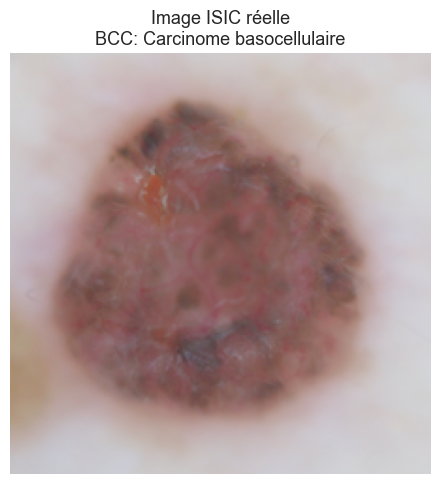

In [27]:
# ============================================
# IMAGE DE DÉMONSTRATION — VRAIE IMAGE ISIC 2019
# ============================================

import random

# Charger le CSV pour avoir les labels
csv_path = os.path.join(DATA_DIR, 'ISIC_2019_Training_GroundTruth.csv')
img_dir  = os.path.join(DATA_DIR, 'ISIC_2019_Training_Input')
df       = pd.read_csv(csv_path)

# Choisir une image par classe (une par run pour la reproductibilité)
DEMO_CLASS = 'BCC'  # Changer ici pour explorer: 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC'

random.seed(SEED)
candidates = df[df[DEMO_CLASS] == 1]['image'].tolist()
img_name   = random.choice(candidates)
img_path   = os.path.join(img_dir, img_name + '.jpg')

# Charger et redimensionner l'image
pil_img  = Image.open(img_path).convert('RGB').resize((IMAGE_SIZE, IMAGE_SIZE))
demo_image = np.array(pil_img).astype(np.float32) / 255.0

# Prétraitement pour les modèles
def preprocess_image(img_array):
    mean = np.array(IMAGENET_MEAN).reshape(1, 1, 3)
    std  = np.array(IMAGENET_STD).reshape(1, 1, 3)
    img_normalized = (img_array - mean) / std
    img_tensor = torch.from_numpy(img_normalized.transpose(2, 0, 1)).float()
    return img_tensor.unsqueeze(0)

demo_tensor = preprocess_image(demo_image).to(device)

# Récupérer la vraie classe
true_class_idx  = CLASS_NAMES.index(DEMO_CLASS)
true_class_full = CLASS_NAMES_FULL[DEMO_CLASS]

print(f"Image sélectionnée : {img_name}.jpg")
print(f"Classe vraie       : {DEMO_CLASS} — {true_class_full}")
print(f"Tensor shape       : {demo_tensor.shape}")

# Visualisation
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(demo_image)
ax.set_title(f"Image ISIC réelle\n{DEMO_CLASS}: {true_class_full}", fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.show()

In [28]:
# ============================================
# PRÉDICTIONS DES 6 MODÈLES
# ============================================

print("Predictions des 6 modeles:\n")
print("="*70)
print(f"{'Modèle':<20} {'Type':<15} {'Prediction':^10} {'Confiance':>10}")
print("-"*70)

predictions = {}

for name, model in models.items():
    model_type = MODELS_CONFIG[name]['type']
    with torch.no_grad():
        output = model(demo_tensor)
        probs = F.softmax(output, dim=1)
        pred_class = probs.argmax(dim=1).item()
        confidence = probs.max().item()

        predictions[name] = {
            'class': pred_class,
            'confidence': confidence,
            'class_name': CLASS_NAMES[pred_class]
        }

        print(f"{name:<20} {model_type:<15} {CLASS_NAMES[pred_class]:^10} {confidence:>10.1%}")

print("="*70)

Predictions des 6 modeles:

Modèle               Type            Prediction  Confiance
----------------------------------------------------------------------
resnet50             CNN                BCC          99.9%
efficientnet_b4      CNN                BCC          99.4%
convnext_base        CNN-Modern         BCC          97.3%
vit_base             Transformer        BCC          86.0%
deit_base            Transformer        BCC          96.5%
swin_base            Transformer        BCC          98.5%


In [29]:
# ============================================
# GÉNÉRER LES EXPLICATIONS POUR LES 6 MODÈLES
# ============================================

print("Generation des explications XAI pour les 6 modeles...\n")

explanations = {}

for model_name, model in models.items():
    model_type = MODELS_CONFIG[model_name]['type']
    pred_class = predictions[model_name]['class']

    print(f"\n{model_name} ({model_type}):")
    explanations[model_name] = {}

    # Grad-CAM (tous les modeles)
    try:
        gradcam = GradCAMExplainer(model, device)
        explanations[model_name]['GradCAM'] = gradcam.explain(demo_tensor, pred_class)
        print("   ✓ Grad-CAM")
    except Exception as e:
        print(f"   ✗ Grad-CAM: {e}")

    # Integrated Gradients (tous les modeles)
    try:
        ig = IntegratedGradientsExplainer(model, device, n_steps=50)
        explanations[model_name]['IntegratedGradients'] = ig.explain(demo_tensor, pred_class)
        print("   ✓ Integrated Gradients")
    except Exception as e:
        print(f"   ✗ Integrated Gradients: {e}")

    # Attention Rollout (ViT/DeiT uniquement)
    if model_name in ['vit_base', 'deit_base']:
        try:
            attn = AttentionRolloutExplainer(model, device)
            explanations[model_name]['AttentionRollout'] = attn.explain(demo_tensor)
            print("   ✓ Attention Rollout")
        except Exception as e:
            print(f"   ✗ Attention Rollout: {e}")

        # Generic Attention (Chefer)
        try:
            generic = GenericAttentionExplainer(model, device)
            explanations[model_name]['GenericAttention'] = generic.explain(demo_tensor, pred_class)
            print("   ✓ Generic Attention (Chefer)")
        except Exception as e:
            print(f"   ✗ Generic Attention: {e}")

print("\n" + "="*50)
print("Toutes les explications generees!")
print("="*50)

Generation des explications XAI pour les 6 modeles...


resnet50 (CNN):
   ✓ Grad-CAM
   ✓ Integrated Gradients

efficientnet_b4 (CNN):
   ✓ Grad-CAM
   ✓ Integrated Gradients

convnext_base (CNN-Modern):
   ✓ Grad-CAM
   ✓ Integrated Gradients

vit_base (Transformer):
   ✓ Grad-CAM
   ✓ Integrated Gradients
   ✓ Attention Rollout
   ✓ Generic Attention (Chefer)

deit_base (Transformer):
   ✓ Grad-CAM
   ✓ Integrated Gradients
   ✓ Attention Rollout
   ✓ Generic Attention (Chefer)

swin_base (Transformer):
   ✓ Grad-CAM
   ✓ Integrated Gradients

Toutes les explications generees!


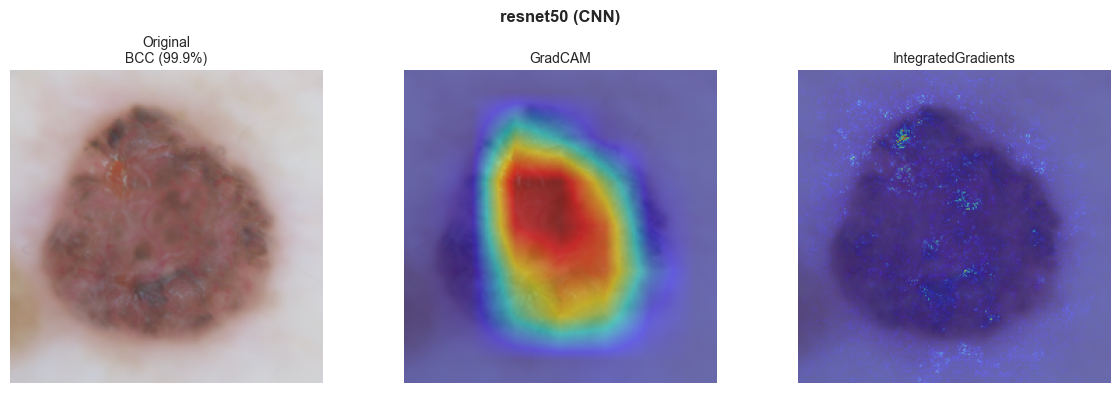

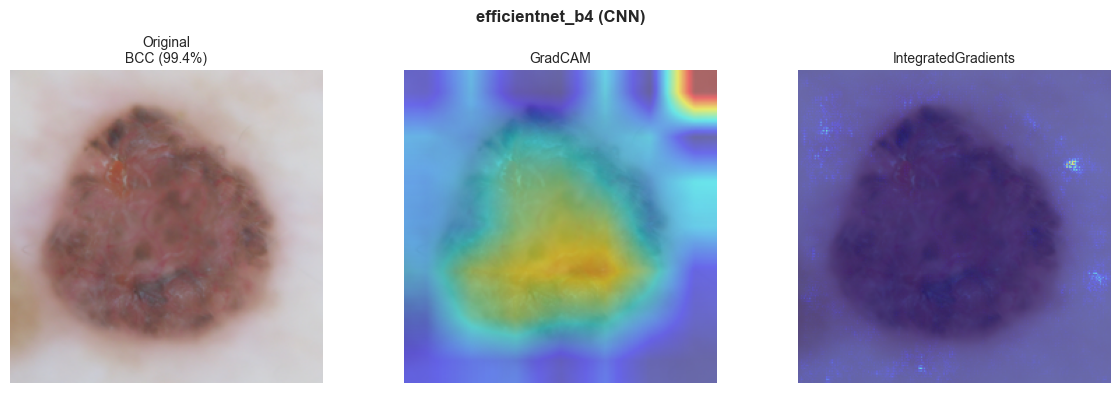

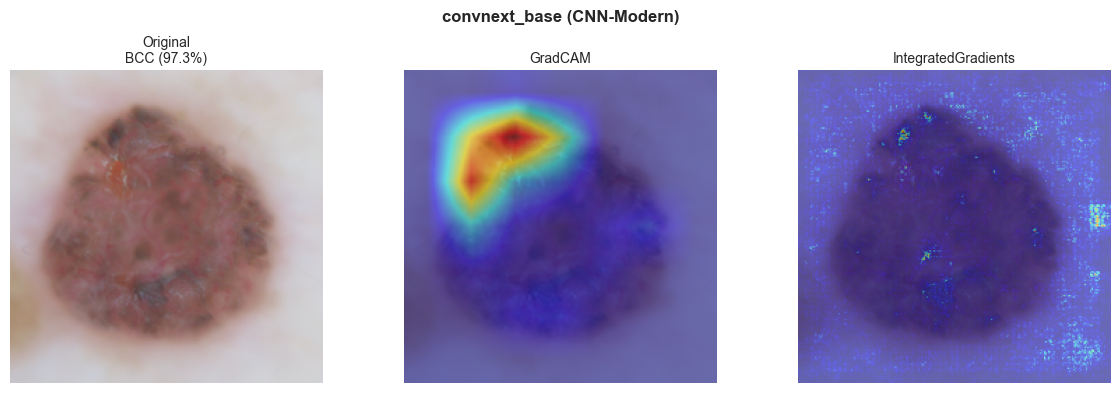

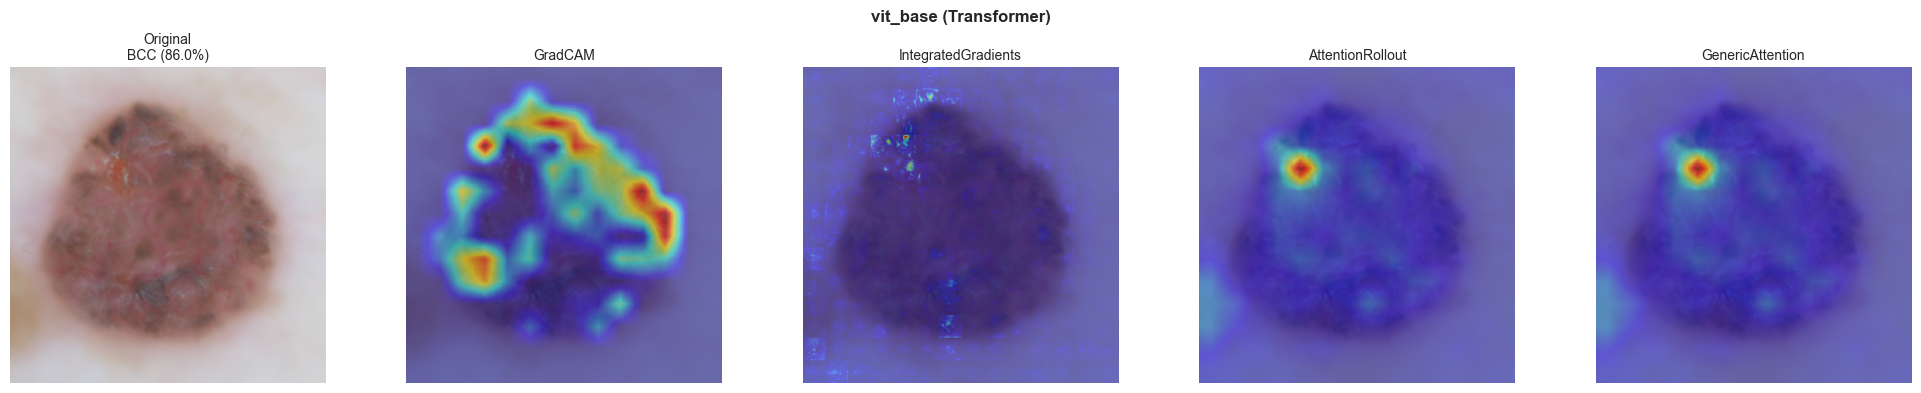

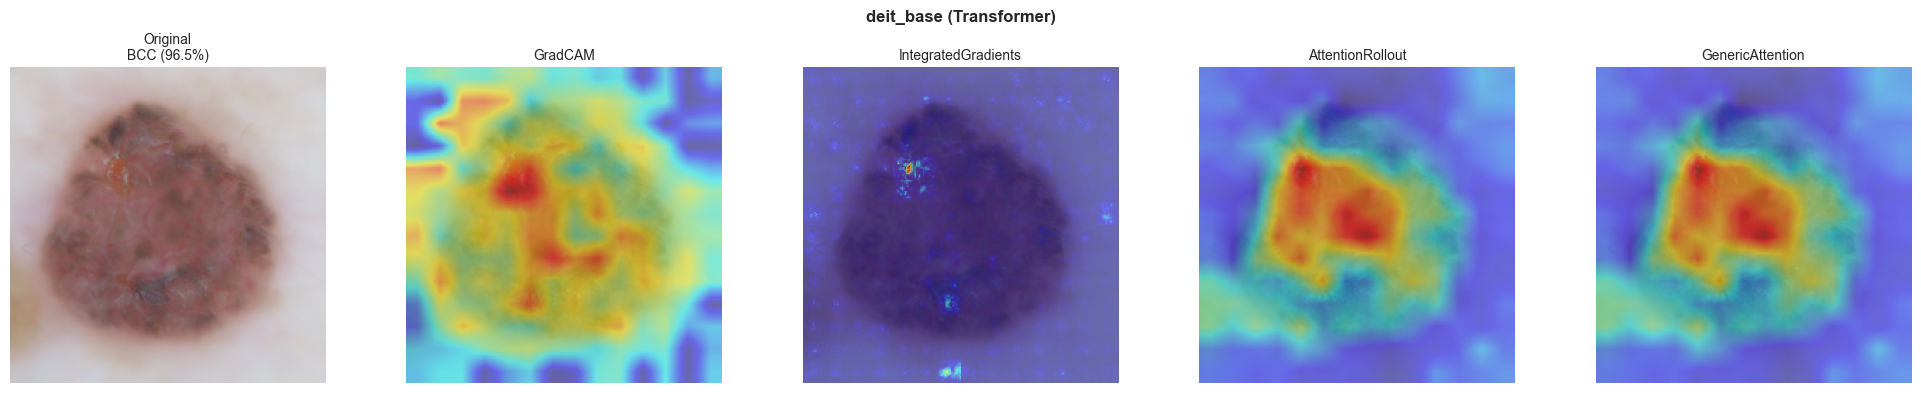

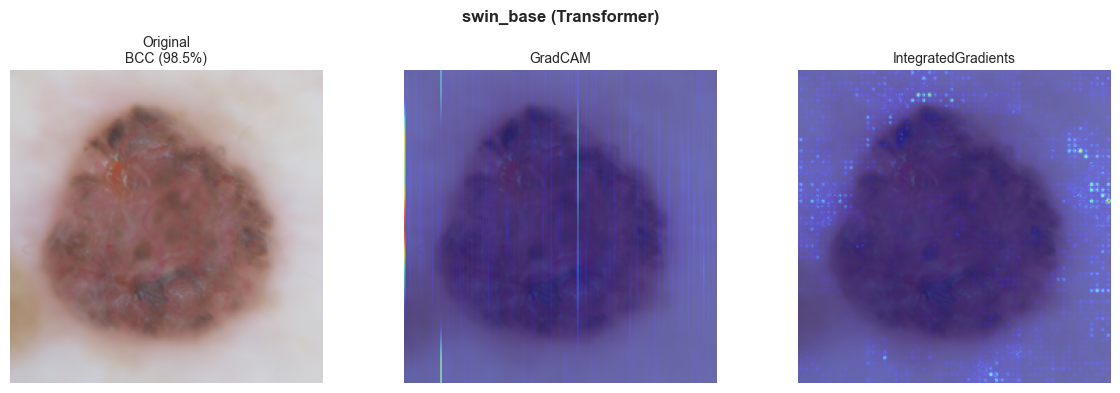

In [30]:
# ============================================
# VISUALISATION DES 6 MODÈLES
# ============================================

def plot_model_explanations(original_image, explanations, model_name, predictions):
    """Visualiser les explications pour un modele."""
    model_expl = explanations.get(model_name, {})
    num_methods = len(model_expl)
    if num_methods == 0:
        return

    fig, axes = plt.subplots(1, num_methods + 1, figsize=(4 * (num_methods + 1), 4))

    axes[0].imshow(original_image)
    pred = predictions[model_name]
    axes[0].set_title(f"Original\n{pred['class_name']} ({pred['confidence']:.1%})", fontsize=10)
    axes[0].axis('off')

    for idx, (method_name, saliency) in enumerate(model_expl.items()):
        ax = axes[idx + 1]
        if saliency.shape != (224, 224):
            saliency = cv2.resize(saliency, (224, 224))
        heatmap = cv2.applyColorMap(np.uint8(255 * saliency), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
        overlay = np.clip(0.5 * heatmap + 0.5 * original_image, 0, 1)
        ax.imshow(overlay)
        ax.set_title(method_name, fontsize=10)
        ax.axis('off')

    plt.suptitle(f"{model_name} ({MODELS_CONFIG[model_name]['type']})", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Visualiser chaque modele
for model_name in models.keys():
    plot_model_explanations(demo_image, explanations, model_name, predictions)

## 7. Évaluation Quantitative

In [31]:
# ============================================
# INSERTION / DELETION AUC
# ============================================

def compute_insertion_deletion(model, input_tensor, saliency_map, target_class, num_steps=100, device='cuda'):
    """
    Calculer les scores d'Insertion et Deletion AUC.

    Insertion: Commence avec image masquee, ajoute les pixels importants
    Deletion: Commence avec image complete, retire les pixels importants
    """
    model.eval()
    input_tensor = input_tensor.to(device)

    if saliency_map.shape != (224, 224):
        saliency_map = cv2.resize(saliency_map, (224, 224))

    flat_saliency = saliency_map.flatten()
    sorted_indices = np.argsort(flat_saliency)[::-1]

    # Ensure input_tensor is detached before converting to numpy
    img_np = input_tensor.squeeze().cpu().detach().numpy()
    baseline = np.zeros_like(img_np)

    num_pixels = 224 * 224
    step_size = num_pixels // num_steps

    insertion_scores = []
    deletion_scores = []

    for step in range(num_steps + 1):
        num_reveal = min(step * step_size, num_pixels)

        mask = np.zeros(num_pixels, dtype=bool)
        mask[sorted_indices[:num_reveal]] = True
        mask = mask.reshape(224, 224)

        insertion_img = baseline.copy()
        deletion_img = img_np.copy()
        for c in range(3):
            insertion_img[c][mask] = img_np[c][mask]
            deletion_img[c][mask] = baseline[c][mask]

        with torch.no_grad():
            ins_tensor = torch.from_numpy(insertion_img).unsqueeze(0).float().to(device)
            del_tensor = torch.from_numpy(deletion_img).unsqueeze(0).float().to(device)

            ins_output = F.softmax(model(ins_tensor), dim=1)
            del_output = F.softmax(model(del_tensor), dim=1)

            insertion_scores.append(ins_output[0, target_class].item())
            deletion_scores.append(del_output[0, target_class].item())

    x = np.linspace(0, 1, len(insertion_scores))
    insertion_auc = np.trapz(insertion_scores, x)
    deletion_auc = np.trapz(deletion_scores, x)

    return insertion_auc, deletion_auc, insertion_scores, deletion_scores

print("Fonctions d'evaluation Insertion/Deletion definies")

Fonctions d'evaluation Insertion/Deletion definies


In [32]:
# ============================================
# ÉVALUER LES MÉTHODES XAI - 6 MODÈLES
# ============================================

print("Evaluation des methodes XAI pour les 6 modeles...\n")

evaluation_results = []

for model_name, model in models.items():
    model_type = MODELS_CONFIG[model_name]['type']
    pred_class = predictions[model_name]['class']
    model_expl = explanations.get(model_name, {})

    print(f"\n{model_name} ({model_type}):")

    for method_name, saliency in model_expl.items():
        try:
            ins_auc, del_auc, _, _ = compute_insertion_deletion(
                model, demo_tensor, saliency, pred_class, device=device
            )
            faithfulness = ins_auc - del_auc

            evaluation_results.append({
                'Model': model_name,
                'Type': model_type,
                'Method': method_name,
                'Insertion AUC': round(ins_auc, 4),
                'Deletion AUC': round(del_auc, 4),
                'Faithfulness': round(faithfulness, 4)
            })
            print(f"   {method_name:25s}: Ins={ins_auc:.3f}, Del={del_auc:.3f}, Faith={faithfulness:.3f}")
        except Exception as e:
            print(f"   {method_name:25s}: Erreur - {e}")

results_df = pd.DataFrame(evaluation_results)
print("\n" + "="*90)
print("TABLEAU RÉCAPITULATIF:")
print("="*90)
print(results_df.to_string(index=False))
print("="*90)

Evaluation des methodes XAI pour les 6 modeles...


resnet50 (CNN):
   GradCAM                  : Ins=0.688, Del=0.311, Faith=0.377
   IntegratedGradients      : Ins=0.061, Del=0.013, Faith=0.048

efficientnet_b4 (CNN):
   GradCAM                  : Ins=0.704, Del=0.359, Faith=0.346
   IntegratedGradients      : Ins=0.190, Del=0.167, Faith=0.023

convnext_base (CNN-Modern):
   GradCAM                  : Ins=0.877, Del=0.390, Faith=0.487
   IntegratedGradients      : Ins=0.505, Del=0.130, Faith=0.375

vit_base (Transformer):
   GradCAM                  : Ins=0.224, Del=0.146, Faith=0.078
   IntegratedGradients      : Ins=0.392, Del=0.092, Faith=0.300
   AttentionRollout         : Ins=0.242, Del=0.163, Faith=0.078
   GenericAttention         : Ins=0.242, Del=0.163, Faith=0.078

deit_base (Transformer):
   GradCAM                  : Ins=0.267, Del=0.085, Faith=0.182
   IntegratedGradients      : Ins=0.182, Del=0.052, Faith=0.130
   AttentionRollout         : Ins=0.409, Del=0.184, Faith=0.

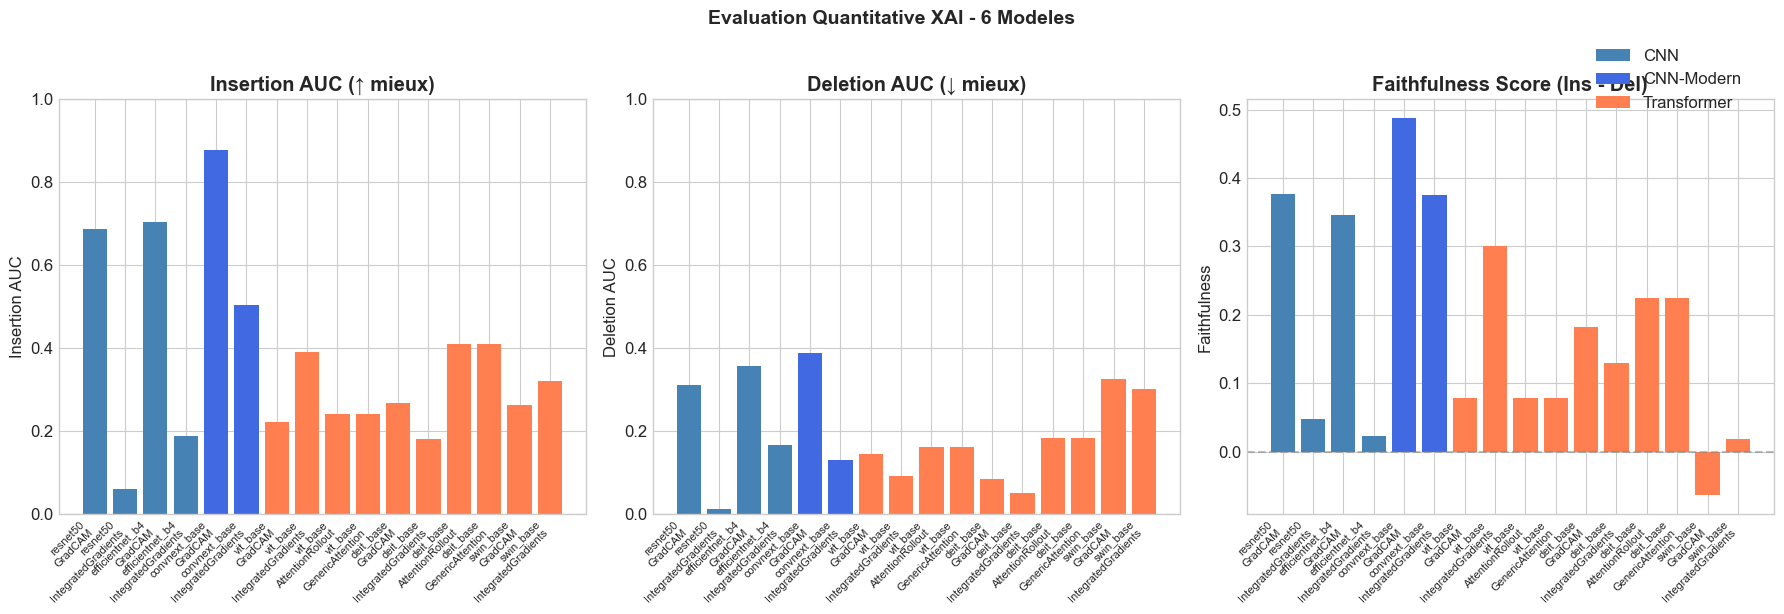

In [33]:
# ============================================
# VISUALISATION COMPARATIVE - 6 MODÈLES
# ============================================

# Couleurs par type de modele
type_colors = {'CNN': 'steelblue', 'CNN-Modern': 'royalblue', 'Transformer': 'coral'}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = [type_colors[r['Type']] for _, r in results_df.iterrows()]

# Insertion AUC
axes[0].bar(range(len(results_df)), results_df['Insertion AUC'], color=colors)
axes[0].set_xticks(range(len(results_df)))
axes[0].set_xticklabels([f"{r['Model']}\n{r['Method']}" for _, r in results_df.iterrows()],
                        rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Insertion AUC')
axes[0].set_title('Insertion AUC (↑ mieux)', fontweight='bold')
axes[0].set_ylim(0, 1)

# Deletion AUC
axes[1].bar(range(len(results_df)), results_df['Deletion AUC'], color=colors)
axes[1].set_xticks(range(len(results_df)))
axes[1].set_xticklabels([f"{r['Model']}\n{r['Method']}" for _, r in results_df.iterrows()],
                        rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Deletion AUC')
axes[1].set_title('Deletion AUC (↓ mieux)', fontweight='bold')
axes[1].set_ylim(0, 1)

# Faithfulness
axes[2].bar(range(len(results_df)), results_df['Faithfulness'], color=colors)
axes[2].set_xticks(range(len(results_df)))
axes[2].set_xticklabels([f"{r['Model']}\n{r['Method']}" for _, r in results_df.iterrows()],
                        rotation=45, ha='right', fontsize=8)
axes[2].set_ylabel('Faithfulness')
axes[2].set_title('Faithfulness Score (Ins - Del)', fontweight='bold')
axes[2].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=t) for t, c in type_colors.items()]
fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.98))

plt.suptitle('Evaluation Quantitative XAI - 6 Modeles', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Sanity Checks

In [34]:
# ============================================
# SANITY CHECKS (Adebayo et al., 2018)
# ============================================

print("Sanity Checks pour les Methodes XAI\n")
print("="*60)
print("Test: Comparer les cartes XAI modele entraine vs aleatoire")
print("Si similaires -> la methode XAI n'est pas fidele au modele")
print("="*60)

# Creer un modele avec poids aleatoires
random_resnet = ModelWrapper('resnet50', NUM_CLASSES, pretrained=False).to(device)
random_resnet.eval()

# Generer Grad-CAM pour les deux modeles
gradcam_trained = GradCAMExplainer(models['resnet50'], device)
gradcam_random = GradCAMExplainer(random_resnet, device)

with torch.no_grad():
    trained_pred = models['resnet50'](demo_tensor).argmax(dim=1).item()
    random_pred = random_resnet(demo_tensor).argmax(dim=1).item()

map_trained = gradcam_trained.explain(demo_tensor, trained_pred)
map_random = gradcam_random.explain(demo_tensor, random_pred)

# Calculer la correlation
correlation = np.corrcoef(map_trained.flatten(), map_random.flatten())[0, 1]

print(f"\nResultat ResNet-50 (Grad-CAM):")
print(f"   Correlation entraine vs aleatoire: {correlation:.3f}")
if abs(correlation) < 0.3:
    print("   Test PASSE: Les cartes sont differentes (methode fidele)")
else:
    print("   Test ECHOUE: Les cartes sont similaires (methode peu fidele)")

Sanity Checks pour les Methodes XAI

Test: Comparer les cartes XAI modele entraine vs aleatoire
Si similaires -> la methode XAI n'est pas fidele au modele

Resultat ResNet-50 (Grad-CAM):
   Correlation entraine vs aleatoire: -0.064
   Test PASSE: Les cartes sont differentes (methode fidele)


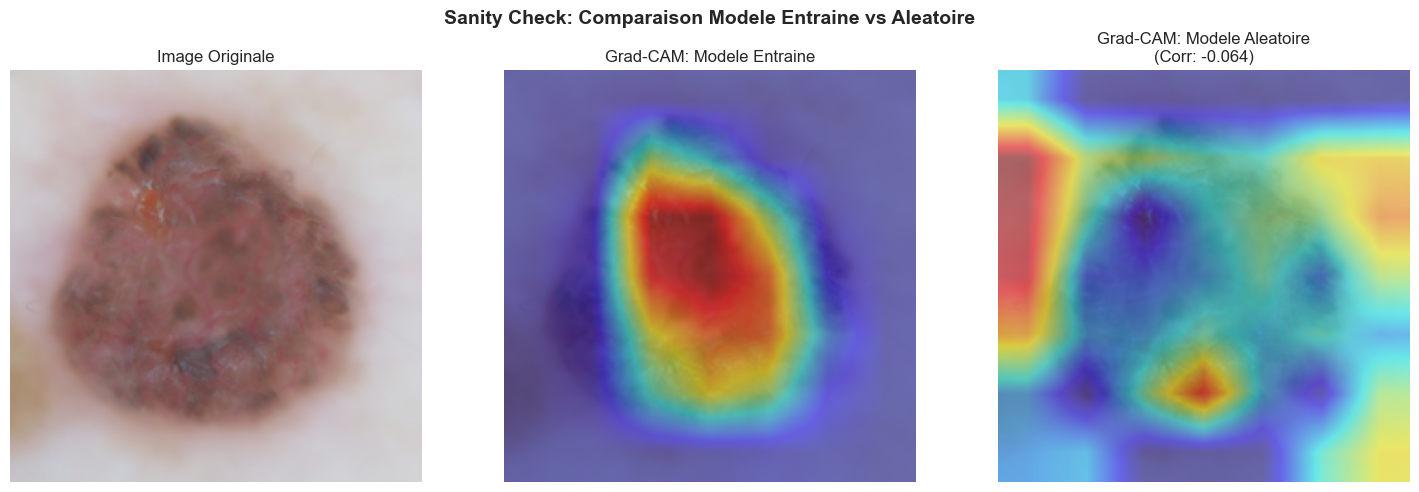

In [35]:
# Visualisation Sanity Check
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(demo_image)
axes[0].set_title("Image Originale", fontsize=12)
axes[0].axis('off')

heatmap1 = cv2.applyColorMap(np.uint8(255 * cv2.resize(map_trained, (224, 224))), cv2.COLORMAP_JET)
heatmap1 = cv2.cvtColor(heatmap1, cv2.COLOR_BGR2RGB) / 255.0
overlay1 = 0.5 * heatmap1 + 0.5 * demo_image
axes[1].imshow(np.clip(overlay1, 0, 1))
axes[1].set_title("Grad-CAM: Modele Entraine", fontsize=12)
axes[1].axis('off')

heatmap2 = cv2.applyColorMap(np.uint8(255 * cv2.resize(map_random, (224, 224))), cv2.COLORMAP_JET)
heatmap2 = cv2.cvtColor(heatmap2, cv2.COLOR_BGR2RGB) / 255.0
overlay2 = 0.5 * heatmap2 + 0.5 * demo_image
axes[2].imshow(np.clip(overlay2, 0, 1))
axes[2].set_title(f"Grad-CAM: Modele Aleatoire\n(Corr: {correlation:.3f})", fontsize=12)
axes[2].axis('off')

plt.suptitle("Sanity Check: Comparaison Modele Entraine vs Aleatoire", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Résumé

In [36]:
# ============================================
# RÉSUMÉ - 6 MODÈLES
# ============================================

print("="*70)
print("           RESUME DES RESULTATS - 6 MODELES")
print("="*70)

print("\nMODELES EVALUES:")
print("-"*50)
for name, model in models.items():
    cfg = MODELS_CONFIG[name]
    params = sum(p.numel() for p in model.parameters())
    print(f"   {name:20s} | {cfg['type']:15s} | {params/1e6:.1f}M params")

print("\nMETHODES XAI IMPLEMENTEES:")
print("-"*50)
methods = [
    ("Grad-CAM", "Tous", "Gradient-based"),
    ("Attention Rollout", "ViT/DeiT", "Attention-based"),
    ("Generic Attention (Chefer)", "ViT/DeiT", "Attention + Gradient"),
    ("Integrated Gradients", "Tous", "Gradient-based"),
    ("LIME", "Tous", "Perturbation-based")
]
for method, compat, category in methods:
    print(f"   {method:30s} | {compat:10s} | {category}")

print("\nCLASSEMENT PAR FAITHFULNESS MOYEN:")
print("-"*50)
ranking = results_df.groupby('Model')['Faithfulness'].mean().sort_values(ascending=False)
for i, (model, faith) in enumerate(ranking.items(), 1):
    model_type = MODELS_CONFIG[model]['type']
    emoji = '🥇' if i == 1 else '🥈' if i == 2 else '🥉' if i == 3 else '  '
    print(f"   {emoji} {i}. {model:20s} ({model_type:12s}): {faith:.4f}")

print("\n" + "="*70)

           RESUME DES RESULTATS - 6 MODELES

MODELES EVALUES:
--------------------------------------------------
   resnet50             | CNN             | 23.5M params
   efficientnet_b4      | CNN             | 17.6M params
   convnext_base        | CNN-Modern      | 87.6M params
   vit_base             | Transformer     | 85.8M params
   deit_base            | Transformer     | 85.8M params
   swin_base            | Transformer     | 99.3M params

METHODES XAI IMPLEMENTEES:
--------------------------------------------------
   Grad-CAM                       | Tous       | Gradient-based
   Attention Rollout              | ViT/DeiT   | Attention-based
   Generic Attention (Chefer)     | ViT/DeiT   | Attention + Gradient
   Integrated Gradients           | Tous       | Gradient-based
   LIME                           | Tous       | Perturbation-based

CLASSEMENT PAR FAITHFULNESS MOYEN:
--------------------------------------------------
   🥇 1. convnext_base        (CNN-Modern  ): 0.4